# LRS TQQQ 当日开仓决策 Notebook

> 目标：基于 LRS 框架，对“今天是否适合开仓 TQQQ”做结构化判断。

分析结构：

1. 基础信号（QQQ vs 200MA）
2. 有效性判断（信号是否可靠）
3. 宏观过滤层（6 指标）
4. 执行层（直接买入 vs 卖 Put）
5. 风控层（给出建议仓位）

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

QQQ = "QQQ"
TQQQ = "TQQQ"
MACRO_TICKERS = ["^IRX", "^FVX", "^TNX", "^TYX", "DX-Y.NYB", "TIP"]

LOOKBACK_YEARS = 2
START = (pd.Timestamp.today() - pd.DateOffset(years=LOOKBACK_YEARS)).strftime("%Y-%m-%d")
END = pd.Timestamp.today().strftime("%Y-%m-%d")

print(f"window: {START} -> {END}")

window: 2024-04-13 -> 2026-04-13


In [2]:
def load_close(ticker: str, start: str, end: str) -> pd.Series:
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(f"no data for {ticker}")
    s = df["Close"].copy()
    s.name = ticker
    return s


def safe_pct_change(s: pd.Series, n: int = 1) -> pd.Series:
    return s.pct_change(n).replace([np.inf, -np.inf], np.nan)


qqq = load_close(QQQ, START, END)
tqqq = load_close(TQQQ, START, END)
macro = pd.concat([load_close(t, START, END) for t in MACRO_TICKERS], axis=1)

print("QQQ last:", round(float(qqq.iloc[-1]), 2))
print("TQQQ last:", round(float(tqqq.iloc[-1]), 2))
print("macro columns:", list(macro.columns))

QQQ last: 611.07
TQQQ last: 49.17
macro columns: ['^IRX', '^FVX', '^TNX', '^TYX', 'DX-Y.NYB', 'TIP']


/var/folders/96/_n1lf8k53dxg2d2mxxmwwjl80000gn/T/ipykernel_21785/1197174451.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("QQQ last:", round(float(qqq.iloc[-1]), 2))
/var/folders/96/_n1lf8k53dxg2d2mxxmwwjl80000gn/T/ipykernel_21785/1197174451.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("TQQQ last:", round(float(tqqq.iloc[-1]), 2))


## 1) 基础信号：QQQ vs 200MA

### 逻辑说明

LRS 的最基础规则：

- `QQQ 收盘 > MA200`：多头可开仓（方向允许）
- `QQQ 收盘 < MA200`：不开新仓/维持离场（方向不允许）

这一步只回答“方向是否允许”，不回答“是否立刻重仓”。

In [3]:
sig = pd.DataFrame(index=qqq.index)
sig["close"] = qqq
sig["ma200"] = qqq.rolling(200).mean()
sig["distance_pct"] = (sig["close"] / sig["ma200"] - 1) * 100
sig["base_long"] = (sig["close"] > sig["ma200"]).astype(int)

today = sig.dropna().iloc[-1]
print("today close:", round(float(today["close"]), 2))
print("today ma200:", round(float(today["ma200"]), 2))
print("distance %:", round(float(today["distance_pct"]), 2))
print("base signal:", "LONG_ALLOWED" if int(today["base_long"]) == 1 else "RISK_OFF")

today close: 611.07
today ma200: 595.32
distance %: 2.65
base signal: LONG_ALLOWED


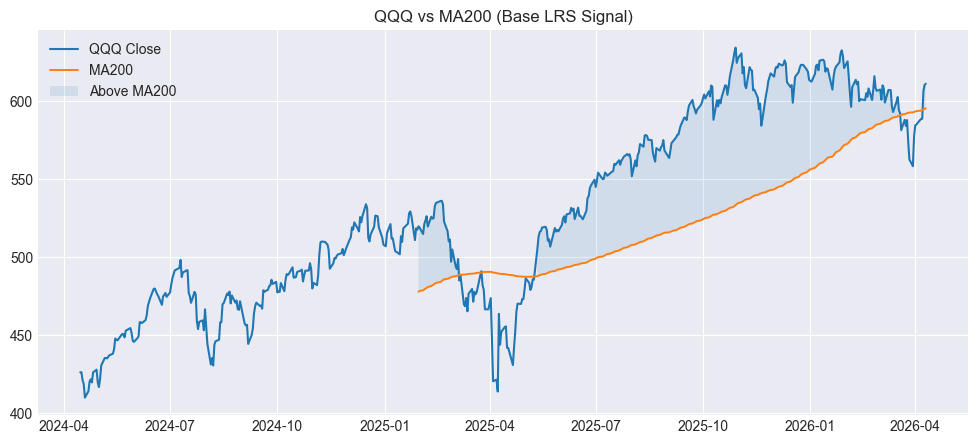

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sig.index, sig["close"], label="QQQ Close", linewidth=1.5)
ax.plot(sig.index, sig["ma200"], label="MA200", linewidth=1.4)
ax.fill_between(
    sig.index,
    sig["close"],
    sig["ma200"],
    where=(sig["close"] > sig["ma200"]),
    alpha=0.12,
    label="Above MA200",
)
ax.set_title("QQQ vs MA200 (Base LRS Signal)")
ax.legend(loc="upper left")
plt.show()

## 2) 有效性判断：信号是否可靠

### 逻辑说明

避免“刚上穿就追、刚下破就砍”的假信号，加入三项确认：

1. 连续 3 日在 MA200 上方（`above_3d`）
2. MA200 斜率为正（`ma200_slope_20 > 0`）
3. 波动不过热（20 日年化波动率低于滚动分位阈值）

满足其中至少 2 项，判定为“有效多头信号”。

In [5]:
val = sig.copy()

# 1) 连续站上 3 日：降低“刚上穿就回落”的假突破噪声
val["above_3d"] = (val["base_long"].rolling(3).sum() == 3).astype(int)

# 2) slope_ok 阈值定义：MA200 的 20 日斜率 > 0 即为 OK
#    含义：长期均线本身在上行，趋势背景更健康
val["ma200_slope_20"] = val["ma200"].diff(20)
val["slope_ok"] = (val["ma200_slope_20"] > 0).astype(int)

# 3) vol_ok 阈值定义：当前 20 日年化波动率 <= 过去 252 日滚动的 75% 分位
#    含义：不过度追逐高波动时段，避免“高噪音追涨”
ret = safe_pct_change(val["close"], 1)
val["vol20_ann"] = ret.rolling(20).std() * np.sqrt(252)
vol_q = val["vol20_ann"].rolling(252).quantile(0.75)
val["vol_ok"] = (val["vol20_ann"] <= vol_q).astype(int)

# 4) valid_score = 三项确认之和
#    为什么阈值是 >=2：
#    - 3 选 2 是“稳健确认”与“信号及时性”的折中
#    - 若要求 3/3，信号会过慢；若只要 1/3，噪声会太多
val["valid_score"] = val[["above_3d", "slope_ok", "vol_ok"]].sum(axis=1)
val["valid_long"] = (val["valid_score"] >= 2).astype(int)

t = val.dropna().iloc[-1]
print("above_3d:", int(t["above_3d"]))
print("slope_ok:", int(t["slope_ok"]), "(rule: ma200_slope_20 > 0)")
print("ma200_slope_20:", round(float(t["ma200_slope_20"]), 4))
print("vol_ok:", int(t["vol_ok"]), "(rule: vol20_ann <= vol_q_75)")
print("vol20_ann:", round(float(t["vol20_ann"]), 4))
print("vol_q_75:", round(float(vol_q.dropna().iloc[-1]), 4))
print("valid_score:", int(t["valid_score"]), "(rule: >= 2)")
print("valid_long:", "YES" if int(t["valid_long"]) == 1 else "NO")

above_3d: 1
slope_ok: 1
vol_ok: 0
valid_score: 2
valid_long: YES


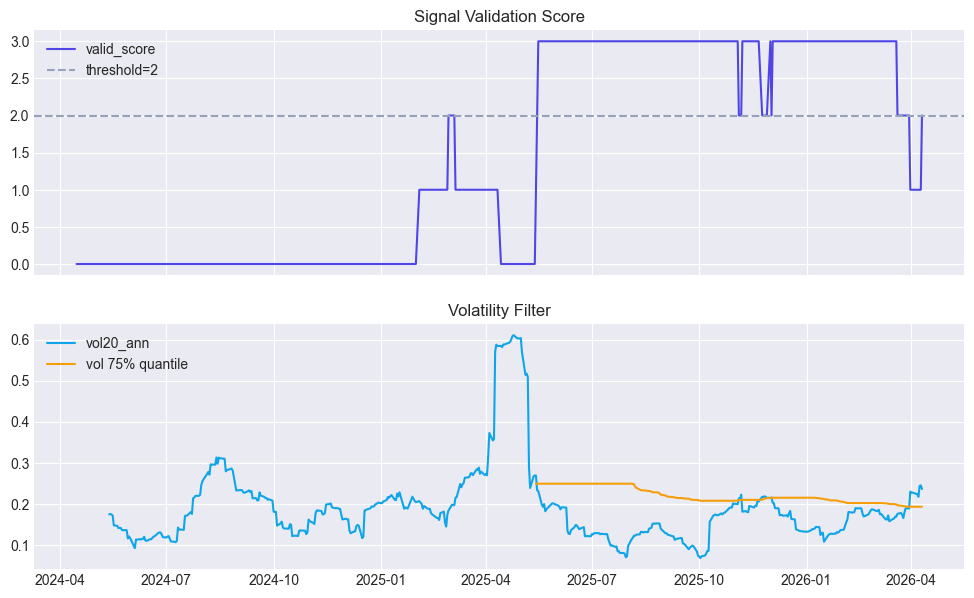

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(val.index, val["valid_score"], label="valid_score", color="#4f46e5")
ax[0].axhline(2, linestyle="--", color="#94a3b8", label="threshold=2")
ax[0].set_title("Signal Validation Score")
ax[0].legend(loc="upper left")

ax[1].plot(val.index, val["vol20_ann"], label="vol20_ann", color="#0ea5e9")
ax[1].plot(vol_q.index, vol_q, label="vol 75% quantile", color="#f59e0b")
ax[1].set_title("Volatility Filter")
ax[1].legend(loc="upper left")
plt.show()

## 3) 宏观过滤层：6 指标记分卡

### 逻辑说明（简化研究版）

以 5 日变化来做方向判断，输出 `macro_score`：

- `IRX` 上升：逆风（-1），下降：顺风（+1）
- `TNX` 上升：逆风（-1），下降：顺风（+1）
- `TIP` 上升：顺风（+1），下降：逆风（-1）
- `DXY` 上升：逆风（-1），下降：顺风（+1）
- `Curve`（TYX-FVX）扩大：顺风（+1），收窄：逆风（-1）

> 这是研究框架的 V0 打分，后续可以细化为幅度分层与阈值区间。

In [7]:
m = macro.copy()
chg5 = m.pct_change(5)

macro_score = pd.Series(0, index=m.index, dtype=float)
macro_detail = pd.DataFrame(index=m.index)

macro_detail["IRX"] = np.where(chg5["^IRX"] <= 0, 1, -1)
macro_detail["TNX"] = np.where(chg5["^TNX"] <= 0, 1, -1)
macro_detail["TIP"] = np.where(chg5["TIP"] >= 0, 1, -1)
macro_detail["DXY"] = np.where(chg5["DX-Y.NYB"] <= 0, 1, -1)

curve = m["^TYX"] - m["^FVX"]
curve_chg = curve.diff(5)
macro_detail["Curve"] = np.where(curve_chg >= 0, 1, -1)

macro_score = macro_detail.sum(axis=1).rename("macro_score")

macro_today = pd.concat([macro_detail, macro_score], axis=1).dropna().iloc[-1]
print("macro score today:", int(macro_today["macro_score"]))
print(macro_today[["IRX", "TNX", "TIP", "DXY", "Curve"]])

macro score today: 3
IRX      1
TNX     -1
TIP      1
DXY      1
Curve    1
Name: 2026-04-10 00:00:00, dtype: int64


/var/folders/96/_n1lf8k53dxg2d2mxxmwwjl80000gn/T/ipykernel_21785/89507757.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  chg5 = m.pct_change(5)


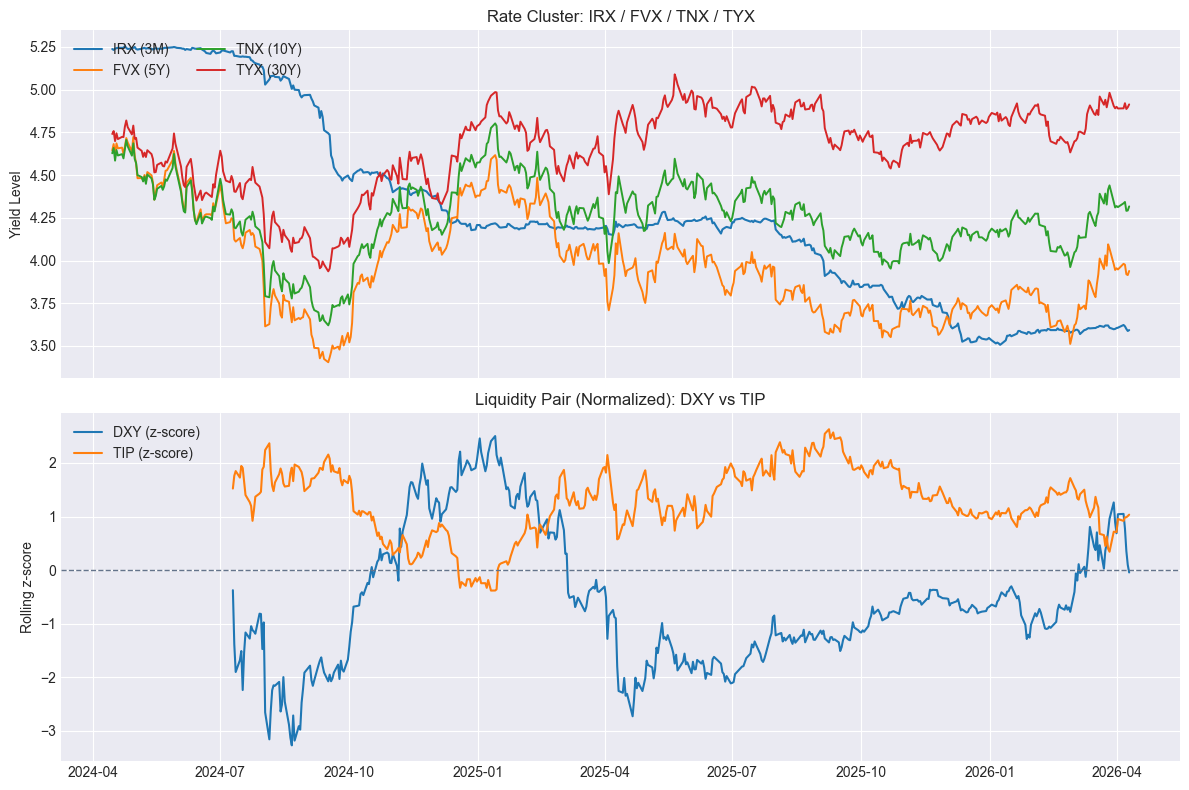

In [9]:
# --- Macro detail charts ---
# 图1：利率组（IRX/FVX/TNX/TYX）放在同一张图，便于看期限结构与方向一致性
rates = m[["^IRX", "^FVX", "^TNX", "^TYX"]].dropna().copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(rates.index, rates["^IRX"], label="IRX (3M)", linewidth=1.5)
axes[0].plot(rates.index, rates["^FVX"], label="FVX (5Y)", linewidth=1.4)
axes[0].plot(rates.index, rates["^TNX"], label="TNX (10Y)", linewidth=1.4)
axes[0].plot(rates.index, rates["^TYX"], label="TYX (30Y)", linewidth=1.4)
axes[0].set_title("Rate Cluster: IRX / FVX / TNX / TYX")
axes[0].set_ylabel("Yield Level")
axes[0].legend(loc="upper left", ncol=2)

# 图2：DXY 与 TIP 量纲不同，先做 z-score 标准化再同图比较趋势
pair = m[["DX-Y.NYB", "TIP"]].dropna().copy()
pair_z = (pair - pair.rolling(252, min_periods=60).mean()) / pair.rolling(252, min_periods=60).std()

axes[1].plot(pair_z.index, pair_z["DX-Y.NYB"], label="DXY (z-score)", linewidth=1.5)
axes[1].plot(pair_z.index, pair_z["TIP"], label="TIP (z-score)", linewidth=1.5)
axes[1].axhline(0, color="#64748b", linestyle="--", linewidth=1)
axes[1].set_title("Liquidity Pair (Normalized): DXY vs TIP")
axes[1].set_ylabel("Rolling z-score")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

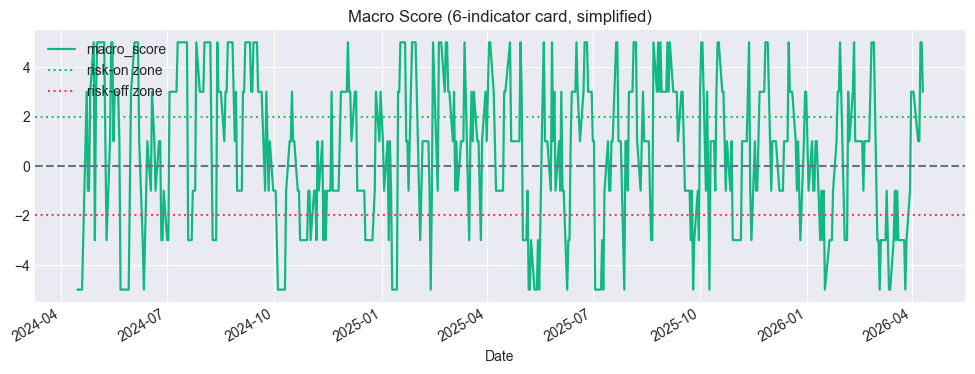

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
macro_score.dropna().plot(ax=ax, color="#10b981", linewidth=1.6)
ax.axhline(0, color="#64748b", linestyle="--")
ax.axhline(2, color="#22c55e", linestyle=":", label="risk-on zone")
ax.axhline(-2, color="#ef4444", linestyle=":", label="risk-off zone")
ax.set_title("Macro Score (6-indicator card, simplified)")
ax.legend(loc="upper left")
plt.show()

## 4) 执行层：买入方式对比（direct buy vs sell put）

### 决策逻辑（当日）

在“方向允许 + 有效性通过 + 宏观不过差”的前提下：

- **direct buy**：适合价格不离谱、趋势确认较强
- **sell put**：适合价格偏高或短期波动偏高，追求更低接盘成本

这里先做“规则评估”，不做完整期权回测（完整回测需期权链、成交与保证金模型）。

In [10]:
decision_df = val.join(macro_score, how="left").ffill()
decision_df["dev_ma20_pct"] = (decision_df["close"] / decision_df["close"].rolling(20).mean() - 1) * 100

d = decision_df.dropna().iloc[-1]
base_ok = int(d["base_long"]) == 1
valid_ok = int(d["valid_long"]) == 1
macro_ok = float(d["macro_score"]) >= -1

entry_allowed = base_ok and valid_ok and macro_ok

if not entry_allowed:
    exec_mode = "NO_ENTRY"
else:
    high_dev = float(d["dev_ma20_pct"]) > 4.0
    high_vol = float(d["vol20_ann"]) > float(val["vol20_ann"].rolling(252).quantile(0.75).dropna().iloc[-1])
    exec_mode = "SELL_PUT" if (high_dev or high_vol) else "DIRECT_BUY"

print("entry_allowed:", entry_allowed)
print("execution_mode:", exec_mode)
print("dev_ma20_pct:", round(float(d["dev_ma20_pct"]), 2))
print("vol20_ann:", round(float(d["vol20_ann"]), 4))

entry_allowed: True
execution_mode: SELL_PUT
dev_ma20_pct: 3.85
vol20_ann: 0.2359


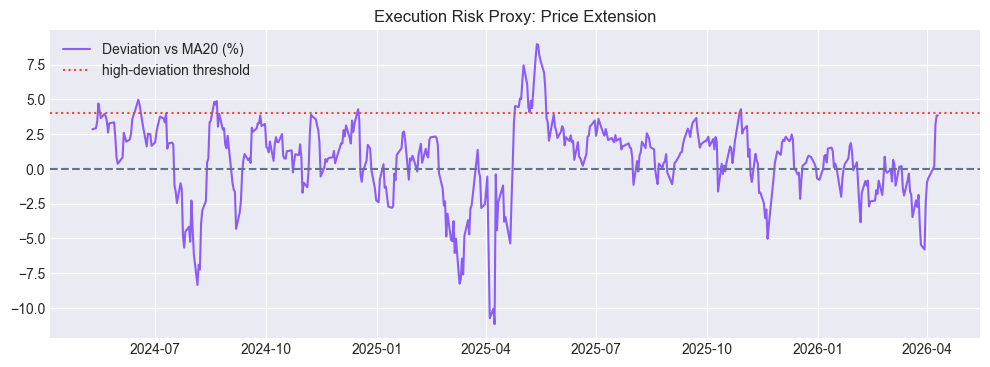

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(decision_df.index, decision_df["dev_ma20_pct"], label="Deviation vs MA20 (%)", color="#8b5cf6")
ax.axhline(4, linestyle=":", color="#ef4444", label="high-deviation threshold")
ax.axhline(0, linestyle="--", color="#64748b")
ax.set_title("Execution Risk Proxy: Price Extension")
ax.legend(loc="upper left")
plt.show()

## 5) 风控层：给出当日建议仓位

### 仓位规则（研究版）

先验前提：

- 若基础信号不允许，仓位直接 0%
- 若有效性不足，仓位降到 0%~30%

当可开仓时，用宏观分数决定仓位：

- `macro_score >= 3` -> 100%
- `macro_score in [1,2]` -> 70%
- `macro_score in [-1,0]` -> 50%
- `macro_score <= -2` -> 0%

最后再叠加执行层调整：

- `SELL_PUT` 模式：权益现货仓位减半（其余转等待接盘/现金）

In [12]:
def position_from_macro(score: float) -> float:
    if score >= 3:
        return 1.0
    if score >= 1:
        return 0.7
    if score >= -1:
        return 0.5
    return 0.0

if not base_ok:
    target_pos = 0.0
elif not valid_ok:
    target_pos = 0.3 if float(d["macro_score"]) >= 1 else 0.0
else:
    target_pos = position_from_macro(float(d["macro_score"]))

if exec_mode == "SELL_PUT":
    target_pos = target_pos * 0.5

conclusion = {
    "base_signal": "LONG_ALLOWED" if base_ok else "RISK_OFF",
    "valid_signal": "PASS" if valid_ok else "FAIL",
    "macro_score": round(float(d["macro_score"]), 2),
    "execution_mode": exec_mode,
    "suggested_tqqq_position": f"{int(target_pos * 100)}%",
}

conclusion

{'base_signal': 'LONG_ALLOWED',
 'valid_signal': 'PASS',
 'macro_score': 3.0,
 'execution_mode': 'SELL_PUT',
 'suggested_tqqq_position': '50%'}

## 6) 实际执行层（实盘细化）：如何下单

这一节把“策略判断”转成“可执行订单”。

分两条路径：

1. `DIRECT_BUY`：直接买入 TQQQ（现货）
2. `SELL_PUT`：卖出现金担保 Put 等待更优接盘

> 原则：执行层服务于上层信号，不反过来推翻风控层。即使执行条件再漂亮，若基础/有效性/宏观不过关，仍不应强行开仓。

### 6.1 DIRECT_BUY：挂什么价位的单（结构化）

#### A. 下单方式

优先级建议：

1. **限价单（Limit）**，避免市价滑点
2. 分批挂单，不一次性打满
3. 首批小单试探，确认成交与波动后再加

#### B. 价格锚点（建议）

用 3 个锚点组合定价：

- `P0`：当前价格
- `VWAP`：当日成交量加权均价（盘中执行时）
- `MA20`：短周期均线（偏离度判断）

可用简化挂单带：

- 第一笔：`min(P0, VWAP) * (1 - 0.1% ~ 0.3%)`
- 第二笔：`MA20` 附近（若价格回踩）
- 第三笔：仅在信号持续且宏观不恶化时触发

#### C. 分批仓位模板

- 首笔 30%
- 二笔 30%
- 三笔 40%

触发逻辑：

- 首笔：信号当天且市场未急剧恶化
- 二笔：回踩不破关键位或次日继续确认
- 三笔：有效性评分维持 + 宏观分数不下降

#### D. 取消/暂停条件

以下任一触发，当天不再追单：

- 价格短时急拉（远离 VWAP/MA20）
- 宏观突发逆转（如利率/美元快速上冲）
- 大盘波动急剧上升（VXN/IV跳升）


### 6.2 SELL_PUT：期权执行框架（详细）

Sell Put 不是“随便卖一个 Put”，核心是：

- 你愿意在该行权价接货
- 权利金与尾部风险匹配
- 流动性足够，能进能出

#### A. 到期日（DTE）建议

优先：`20-45 DTE`（常用甜区）

- 太短（<14 DTE）：Gamma 风险高，波动冲击大
- 太长（>60 DTE）：资金占用久，年化效率下降

#### B. 行权价与 Delta

优先卖 OTM Put：

- 目标 Delta：`0.20 ~ 0.35`
  - Delta 太高（>0.40）：接货概率高，防守不足
  - Delta 太低（<0.15）：权利金可能太薄，不划算

#### C. Gamma 风险

- 优先低 Gamma 合约（尤其在临近到期时）
- 若 Gamma 偏高，需降低仓位或延长 DTE

#### D. PCR（Put/Call Ratio）

- 作为情绪过滤，不单独做交易触发
- 可用阈值示例：
  - PCR 过高：市场恐慌，需提高安全边际
  - PCR 过低：过度乐观，警惕回撤

#### E. IV vs HV

这是 Sell Put 的核心定价逻辑：

- 当 `IV / HV` 足够高（例如 > 1.1~1.3）时，卖方定价更有优势
- 当 IV 太低（接近或低于 HV）时，常见问题：
  - 权利金太少
  - 赔付尾部风险不变
  - 风险收益比失衡

**结论**：IV 太低时宁可等待，不为“有单可下”而下单。

#### F. 成交量与持仓量（Liquidity）

最低流动性建议（示例）：

- 单腿日成交量 >= 100
- 持仓量 OI >= 500
- Bid-Ask 相对价差 <= 10%

不满足则谨慎：流动性差时，进场和止损成本都会变高。


In [13]:
# SELL_PUT 候选筛选器（代码骨架）
# 说明：yfinance 的期权希腊值并不完整，若 delta/gamma 缺失，这里会使用近似或标记为 NaN。

import math
from scipy.stats import norm


def bs_put_delta_gamma(S, K, T, r, sigma):
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan, np.nan
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * math.sqrt(T))
    return delta, gamma


def pick_put_candidates(ticker="TQQQ", rf=0.045):
    tk = yf.Ticker(ticker)
    expiries = tk.options
    if not expiries:
        return pd.DataFrame()

    spot = float(tk.history(period="1d")["Close"].iloc[-1])
    rows = []

    # 基于历史波动做 IV 缺失时的兜底近似
    hist = tk.history(period="1y")["Close"]
    hv20 = float(hist.pct_change().rolling(20).std().dropna().iloc[-1] * np.sqrt(252)) if len(hist) > 40 else np.nan

    for exp in expiries:
        try:
            chain = tk.option_chain(exp)
            puts = chain.puts.copy()
        except Exception:
            continue

        if puts.empty:
            continue

        dte = (pd.Timestamp(exp) - pd.Timestamp.today().normalize()).days
        if dte < 14 or dte > 60:
            continue

        puts = puts.dropna(subset=["strike", "bid", "ask"])
        puts["mid"] = (puts["bid"] + puts["ask"]) / 2
        puts = puts[puts["mid"] > 0]

        for _, r0 in puts.iterrows():
            K = float(r0["strike"])
            iv = float(r0["impliedVolatility"]) if pd.notna(r0.get("impliedVolatility", np.nan)) else np.nan
            sigma = iv if pd.notna(iv) and iv > 0 else hv20
            T = max(dte, 1) / 365.0

            delta, gamma = bs_put_delta_gamma(spot, K, T, rf, sigma) if pd.notna(sigma) else (np.nan, np.nan)
            spread_pct = (float(r0["ask"]) - float(r0["bid"])) / max(float(r0["mid"]), 1e-6)

            rows.append(
                {
                    "expiry": exp,
                    "dte": dte,
                    "strike": K,
                    "mid": float(r0["mid"]),
                    "iv": iv,
                    "hv20": hv20,
                    "iv_hv_ratio": (iv / hv20) if pd.notna(iv) and pd.notna(hv20) and hv20 > 0 else np.nan,
                    "delta": delta,
                    "gamma": gamma,
                    "volume": float(r0.get("volume", np.nan)) if pd.notna(r0.get("volume", np.nan)) else 0.0,
                    "oi": float(r0.get("openInterest", np.nan)) if pd.notna(r0.get("openInterest", np.nan)) else 0.0,
                    "spread_pct": spread_pct,
                    "otm_pct": (spot - K) / spot,
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    # 规则过滤
    out = out[(out["delta"].abs() >= 0.20) & (out["delta"].abs() <= 0.35)]
    out = out[out["spread_pct"] <= 0.10]
    out = out[(out["volume"] >= 100) & (out["oi"] >= 500)]

    # 打分（可按需要调整权重）
    out["score"] = (
        out["iv_hv_ratio"].fillna(0) * 0.35
        + (0.35 - out["delta"].abs()).clip(lower=0) * 0.25
        + (1 - out["spread_pct"]).clip(lower=0) * 0.20
        + np.log1p(out["oi"]) / 10 * 0.20
    )

    return out.sort_values("score", ascending=False)


put_candidates = pick_put_candidates("TQQQ")
put_candidates.head(10)

,expiry,dte,strike,mid,iv,hv20,iv_hv_ratio,delta,gamma,volume,oi,spread_pct,otm_pct,score
124,2026-05-15,31,43.0,1.470,0.694827,0.700283,0.992210,-0.212340,0.029040,429.0,1894.0,0.054422,0.128320,0.721743
25,2026-05-01,17,44.0,1.095,0.719729,0.700283,1.027770,-0.204034,0.036977,424.0,579.0,0.009132,0.108048,0.721645
126,2026-05-15,31,45.0,1.905,0.650882,0.700283,0.929457,-0.274481,0.035626,836.0,3620.0,0.036745,0.087776,0.700731
27,2026-05-01,17,45.0,1.270,0.687015,0.700283,0.981054,-0.239505,0.042456,4761.0,1106.0,0.062992,0.087776,0.698582
83,2026-05-08,24,45.0,1.600,0.664554,0.700283,0.948980,-0.260539,0.038628,226.0,696.0,0.087500,0.087776,0.667944
127,2026-05-15,31,46.0,2.215,0.638675,0.700283,0.912025,-0.312387,0.038551,114.0,516.0,0.067720,0.067505,0.640029


### SELL_PUT 候选筛选器说明（这段代码做了什么）

这段代码分为 **3 步：拉数据 -> 过滤 -> 打分排序**。

#### 1) 数据层（拉取与补全）

- 拉取 `TQQQ` 全部可用到期日的 Put 期权链
- 只保留 `14 ~ 60 DTE` 的合约（避免太短 Gamma 风险、太长资金效率低）
- 计算中间价：`mid = (bid + ask) / 2`
- 若 `impliedVolatility` 缺失，用 `hv20`（20日历史年化波动）做近似兜底
- 用 Black-Scholes 近似计算 `delta/gamma`（当源数据无希腊值时）

#### 2) 规则过滤（硬门槛）

候选合约必须同时满足：

- `|delta|` 在 `[0.20, 0.35]`
  - 目标是“有权利金但不过度激进”的 OTM Put 区间
- `spread_pct <= 0.10`
  - 价差不能太宽，避免进出场滑点过大
- `volume >= 100` 且 `oi >= 500`
  - 保证基本流动性，降低成交与平仓风险

#### 3) 打分公式（软排序）

过滤后再做综合评分：

`score = 0.35*iv_hv_ratio + 0.25*(0.35-|delta|) + 0.20*(1-spread_pct) + 0.20*log1p(oi)/10`

含义：

- `iv_hv_ratio`（权重 35%）：
  - IV 相对 HV 越高，卖方定价优势越大
- `delta 距离`（权重 25%）：
  - 越接近保守端（接近 0.20）越高分
- `价差质量`（权重 20%）：
  - `spread_pct` 越小越好
- `持仓深度`（权重 20%）：
  - OI 越高，流动性通常越好（用 `log1p` 防止极端值主导）

最终按 `score` 从高到低排序，`head(10)` 输出优先候选。

> 注意：这是研究版评分器，不等于自动交易指令。实盘前仍需人工复核：宏观状态、事件风险（财报/FOMC）、仓位上限、单笔最大亏损容忍度。

### 6.3 IV 太低时怎么决策（关键）

这是你提到的核心难题：

- 如果 IV 太低，卖 Put 权利金很薄
- 但尾部风险（单边下跌）并没有消失
- 风险收益比会明显变差

建议决策顺序：

1. 若 `iv_hv_ratio < 1.0~1.1`：
   - 默认 **不卖 Put**
   - 若必须建仓，倾向少量 direct buy 或等待回踩
2. 若 `iv_hv_ratio >= 1.2` 且流动性达标：
   - 才考虑 sell put
3. 若宏观分数偏弱（<=0）：
   - 即使 IV 看起来够高，也要降仓/减频

一句话：**低 IV 不是“安全”，而是“卖方补偿不足”。**

In [15]:
# 最终执行建议汇总（把前面结果串起来）
summary = {}
summary["base_signal"] = "LONG_ALLOWED" if base_ok else "RISK_OFF"
summary["valid_signal"] = "PASS" if valid_ok else "FAIL"
summary["macro_score"] = float(d["macro_score"])
summary["execution_mode"] = exec_mode
summary["target_position"] = float(target_pos)

if exec_mode == "DIRECT_BUY":
    # 示例挂单建议（可按你的券商规则微调）
    latest = float(decision_df["close"].iloc[-1])
    ma20 = float(decision_df["close"].rolling(20).mean().iloc[-1])
    vwap_proxy = latest  # 若有分钟级数据，可替换为真实盘中 VWAP

    p1 = min(latest, vwap_proxy) * (1 - 0.002)
    p2 = ma20
    summary["direct_buy_plan"] = {
        "batch_1_30pct_limit": round(p1, 2),
        "batch_2_30pct_limit": round(p2, 2),
        "batch_3_40pct": "仅在信号持续+宏观不恶化时执行",
    }

elif exec_mode == "SELL_PUT":
    if put_candidates.empty:
        summary["sell_put_plan"] = "未找到满足筛选条件的候选合约，建议等待或改为小仓位 direct buy"
    else:
        top = put_candidates.iloc[0]
        summary["sell_put_plan"] = {
            "expiry": str(top["expiry"]),
            "dte": int(top["dte"]),
            "strike": round(float(top["strike"]), 2),
            "delta_abs": round(abs(float(top["delta"])), 3),
            "iv_hv_ratio": round(float(top["iv_hv_ratio"]), 3) if pd.notna(top["iv_hv_ratio"]) else None,
            "volume": int(top["volume"]),
            "open_interest": int(top["oi"]),
            "spread_pct": round(float(top["spread_pct"]), 4),
        }

summary

{'base_signal': 'LONG_ALLOWED',
 'valid_signal': 'PASS',
 'macro_score': 3.0,
 'execution_mode': 'SELL_PUT',
 'target_position': 0.5,
 'sell_put_plan': {'expiry': '2026-05-15',
  'dte': 31,
  'strike': 43.0,
  'delta_abs': 0.212,
  'iv_hv_ratio': 0.992,
  'volume': 429,
  'open_interest': 1894,
  'spread_pct': 0.0544}}

## 8) 结果可视化增强（过去 30 天）

下面补充三类图，帮助更直观地判断当前执行环境：

1. **IV vs HV（30 天）**：观察卖方定价优势是否成立
2. **PCR（30 天）**：观察市场情绪冷热变化
3. **成交量（30 天）**：观察流动性是否支持执行

> 说明：免费数据源下，`QQQ` 的完整历史期权 IV 与期权成交量时间序列较难稳定获取。
> 因此这里采用“可复现口径”：
> - IV：优先使用 `VXN` 作为 QQQ 隐含波动代理（除以 100）
> - PCR：优先尝试 `^PCALL`，若不可得则给出替代提示
> - 成交量：使用 `TQQQ/QQQ` 标的成交量 30 日走势 + 当前期权链横截面

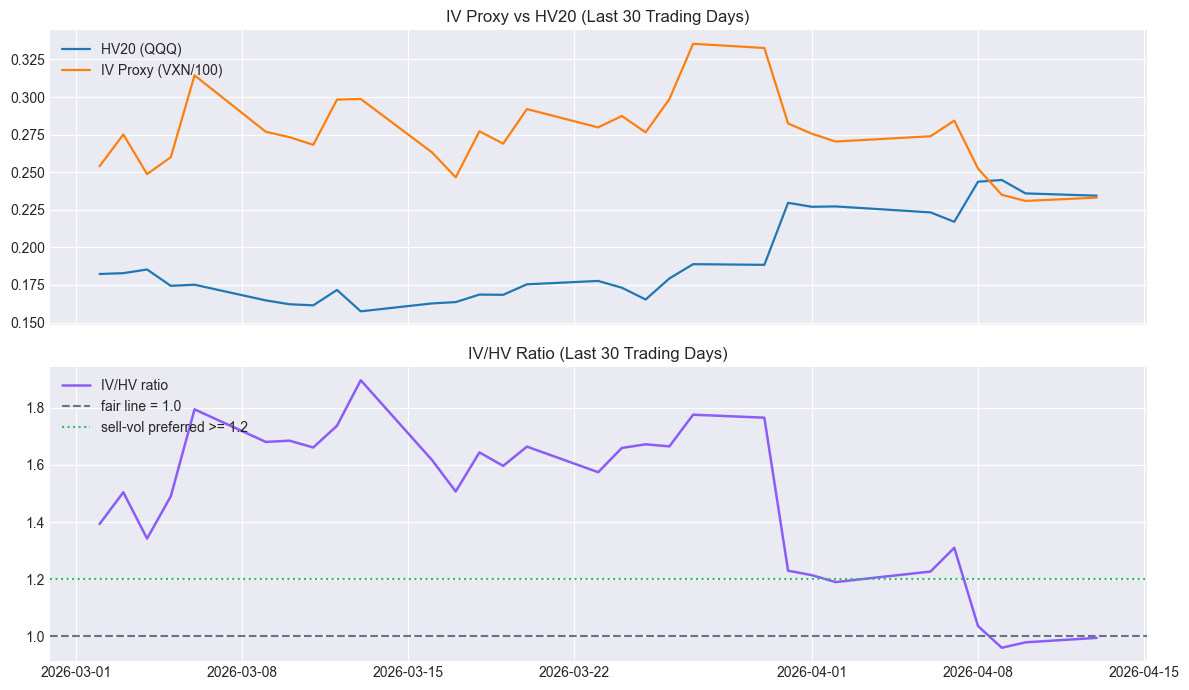

,hv20,iv_proxy,iv_hv_ratio
Date,,,
2026-04-07,0.217019,0.2843,1.310025
2026-04-08,0.243678,0.2524,1.035793
2026-04-09,0.244842,0.2350,0.959803
2026-04-10,0.235904,0.2309,0.978790
2026-04-13,0.234383,0.2331,0.994526


In [17]:
# IV proxy vs HV (last 30 trading days)
qqq_hist = yf.download("QQQ", period="1y", auto_adjust=True, progress=False)
qqq_close = qqq_hist["Close"]
if isinstance(qqq_close, pd.DataFrame):
    qqq_close = qqq_close.iloc[:, 0]
qqq_close = qqq_close.dropna()

hv20_full = qqq_close.pct_change().rolling(20).std() * np.sqrt(252)

# VXN 作为 QQQ 隐含波动代理（百分比 -> 小数）
vxn_df = yf.download("^VXN", period="1y", auto_adjust=True, progress=False)
if vxn_df.empty:
    iv_proxy_full = pd.Series(dtype=float, name="iv_proxy")
else:
    vxn_close = vxn_df["Close"]
    if isinstance(vxn_close, pd.DataFrame):
        vxn_close = vxn_close.iloc[:, 0]
    iv_proxy_full = (vxn_close / 100.0).rename("iv_proxy")

iv_hv = pd.concat([hv20_full.rename("hv20"), iv_proxy_full], axis=1).dropna()
iv_hv_30 = iv_hv.tail(30).copy()
iv_hv_30["iv_hv_ratio"] = iv_hv_30["iv_proxy"] / iv_hv_30["hv20"]

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(iv_hv_30.index, iv_hv_30["hv20"], label="HV20 (QQQ)", linewidth=1.6)
ax[0].plot(iv_hv_30.index, iv_hv_30["iv_proxy"], label="IV Proxy (VXN/100)", linewidth=1.6)
ax[0].set_title("IV Proxy vs HV20 (Last 30 Trading Days)")
ax[0].legend(loc="upper left")

ax[1].plot(iv_hv_30.index, iv_hv_30["iv_hv_ratio"], label="IV/HV ratio", color="#8b5cf6", linewidth=1.8)
ax[1].axhline(1.0, color="#64748b", linestyle="--", label="fair line = 1.0")
ax[1].axhline(1.2, color="#22c55e", linestyle=":", label="sell-vol preferred >= 1.2")
ax[1].set_title("IV/HV Ratio (Last 30 Trading Days)")
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

iv_hv_30.tail()

In [18]:
# PCR 30-day trend (preferred: ^PCALL)
pcr_df = yf.download("^PCALL", period="3mo", auto_adjust=True, progress=False)

if not pcr_df.empty:
    pcr = pcr_df["Close"].dropna().tail(30)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pcr.index, pcr.values, color="#f59e0b", linewidth=1.8, label="PCR (^PCALL)")
    ax.axhline(pcr.mean(), color="#64748b", linestyle="--", label=f"30d mean={pcr.mean():.2f}")
    ax.set_title("Put/Call Ratio (Last 30 Trading Days)")
    ax.legend(loc="upper left")
    plt.show()
    display(pcr.tail().to_frame("PCR"))
else:
    print("未能从 ^PCALL 获取30天PCR时间序列。")
    print("替代方案：使用当前期权链横截面估算 PCR（按成交量/持仓量），并在日更任务中落盘形成时间序列。")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^PCALL"}}}
$^PCALL: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['^PCALL']: possibly delisted; no price data found  (period=3mo) (Yahoo error = "No data found, symbol may be delisted")


未能从 ^PCALL 获取30天PCR时间序列。
替代方案：使用当前期权链横截面估算 PCR（按成交量/持仓量），并在日更任务中落盘形成时间序列。


In [19]:
# Volume trend (underlying) + option-chain cross-section
qqq_30 = yf.download("QQQ", period="3mo", auto_adjust=True, progress=False)
tqqq_30 = yf.download("TQQQ", period="3mo", auto_adjust=True, progress=False)

vol_df = pd.DataFrame(
    {
        "QQQ_volume": qqq_30["Volume"].dropna().tail(30),
        "TQQQ_volume": tqqq_30["Volume"].dropna().tail(30),
    }
).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol_df.index, vol_df["QQQ_volume"] / 1e6, label="QQQ Volume (M)", linewidth=1.6)
ax.plot(vol_df.index, vol_df["TQQQ_volume"] / 1e6, label="TQQQ Volume (M)", linewidth=1.6)
ax.set_title("Underlying Volume Trend (Last 30 Trading Days)")
ax.set_ylabel("Millions")
ax.legend(loc="upper left")
plt.show()

# 当前期权链横截面：按到期日聚合 put/call 成交量与持仓量
try:
    tk = yf.Ticker("TQQQ")
    rows = []
    for exp in tk.options[:8]:  # 取前几个到期日，避免图过密
        ch = tk.option_chain(exp)
        put_vol = float(ch.puts["volume"].fillna(0).sum()) if not ch.puts.empty else 0.0
        call_vol = float(ch.calls["volume"].fillna(0).sum()) if not ch.calls.empty else 0.0
        put_oi = float(ch.puts["openInterest"].fillna(0).sum()) if not ch.puts.empty else 0.0
        call_oi = float(ch.calls["openInterest"].fillna(0).sum()) if not ch.calls.empty else 0.0
        rows.append(
            {
                "expiry": exp,
                "put_vol": put_vol,
                "call_vol": call_vol,
                "put_oi": put_oi,
                "call_oi": call_oi,
                "pcr_vol": put_vol / call_vol if call_vol > 0 else np.nan,
                "pcr_oi": put_oi / call_oi if call_oi > 0 else np.nan,
            }
        )
    cross = pd.DataFrame(rows)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    x = np.arange(len(cross))
    w = 0.38
    ax[0].bar(x - w / 2, cross["put_vol"], width=w, label="Put Vol")
    ax[0].bar(x + w / 2, cross["call_vol"], width=w, label="Call Vol")
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(cross["expiry"], rotation=45, ha="right")
    ax[0].set_title("Option Volume by Expiry (TQQQ)")
    ax[0].legend()

    ax[1].plot(cross["expiry"], cross["pcr_vol"], marker="o", label="PCR by Volume")
    ax[1].plot(cross["expiry"], cross["pcr_oi"], marker="o", label="PCR by OI")
    ax[1].axhline(1.0, linestyle="--", color="#64748b")
    ax[1].set_xticklabels(cross["expiry"], rotation=45, ha="right")
    ax[1].set_title("Cross-sectional PCR (Current Chain)")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    display(cross)
except Exception as exc:
    print("期权链横截面绘图失败:", exc)

ValueError: If using all scalar values, you must pass an index

## 7) 当日执行检查清单（Checklist）

下单前最后确认：

- [ ] 基础信号允许（QQQ 在 MA200 上方）
- [ ] 有效性通过（`valid_score >= 2`）
- [ ] 宏观分数不逆风（至少不低于你设定阈值）
- [ ] 执行方式与波动环境匹配（Direct Buy / Sell Put）
- [ ] 若 Sell Put：DTE、Delta、IV/HV、流动性都达标
- [ ] 仓位不超过风控上限

> 如果有 2 项以上不满足，默认降仓或放弃当日开仓。

## 结论模板（执行前复核）

请在每次实际下单前，复核以下四点：

1. `base_signal` 是否允许开仓（QQQ 是否站上 MA200）
2. `valid_signal` 是否通过（避免假信号）
3. `macro_score` 是否支持风险暴露
4. `execution_mode` 是否匹配当前价格与波动状态

> 如果结论与主观判断冲突，优先降低仓位而不是强行重仓。